# Stabilized Conditional Diffusion GMV — Full Pipeline

**One notebook, end to end.**  Run cells top to bottom.

| Phase | What happens |
|---|---|
| 0 – WRDS Pull | Query CRSP and save `data/raw/crsp_daily.parquet` |
| 1 – Clean | Filter, delisting-adjust, compute ME |
| 2 – Universe & Groups | Calendar, top-500, sleeves |
| 3 – Covariance Datasets | Ridge-log-vech transform, training-only scalers |
| 4 – Train | 4 conditional DDPM models (linear schedule × T ∈ {400, 800, 1200, 2000}) |
| 5 – Validate | 81 configurations → select one |
| 6 – Test | Untouched 2021–2025 backtest + benchmarks |
| 7 – Report | Figures + final Markdown report |
| ✓ – Tests | `pytest tests/` |
| 📊 – Summary | Display key results inline |

> **Training note:** Phase 4 trains 4 neural networks for 200 epochs each.  
> Larger T values (T=1200, T=2000) have longer per-epoch time due to more diffusion steps.  
> Expect ~1–2 h on GPU (MPS/CUDA) or many hours on CPU.  
> Previously completed checkpoints are **skipped automatically**.


## 0 · Setup

In [1]:
import os, sys
from pathlib import Path

# ── Change to project root ────────────────────────────────────────────────────
PROJECT_ROOT = Path(__file__).resolve().parent if '__file__' in dir() else Path.cwd()
# If we are inside the notebook directory, walk up until we find the project folder
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "src" / "config.py").exists():
        PROJECT_ROOT = candidate
        break

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print("Working directory:", PROJECT_ROOT)
print("Python:", sys.executable)


Working directory: /Users/brianrhie/Documents/Quant/Find-A/Final/final_sprint_cov_diffusion
Python: /opt/anaconda3/bin/python


In [2]:
# Quick dependency check
import importlib, subprocess

required = [
    "numpy", "pandas", "torch", "cvxpy", "scipy",
    "sklearn", "yaml", "matplotlib", "tqdm",
]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    print("Installing:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)
else:
    print("All dependencies present ✓")


All dependencies present ✓


In [3]:
# ── GPU / device status ───────────────────────────────────────────────────────
import torch

def _get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    try:
        if torch.backends.mps.is_available():
            return torch.device("mps")
    except AttributeError:
        pass
    return torch.device("cpu")

device = _get_device()
print(f"PyTorch version : {torch.__version__}")
print(f"Compute device  : {device}")

if device.type == "cuda":
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        mem_gb = props.total_memory / 1e9
        print(f"  GPU {i}: {props.name}  ({mem_gb:.1f} GB VRAM)")
elif device.type == "mps":
    print("  Apple Silicon MPS backend active.")
else:
    print("  ⚠️  No GPU found — training will use CPU (slower).")
    print("     Estimated time on CPU: ~4–6 h per model (9 models total).")


PyTorch version : 2.11.0
Compute device  : mps
  Apple Silicon MPS backend active.


---
## Phase 0 · WRDS Data Pull

Pulls `crsp.dsf`, `crsp.dsenames`, and `crsp.dsedelist`, then merges them
into `data/raw/crsp_daily.parquet`.

> **Skip this section** if `data/raw/crsp_daily.parquet` already exists.


In [4]:
raw_path = PROJECT_ROOT / "data" / "raw" / "crsp_daily.parquet"

if raw_path.exists():
    import pandas as pd
    _info = pd.read_parquet(raw_path, columns=["date"])
    print(f"✓  Raw file already exists ({len(_info):,} rows). Skipping WRDS pull.")
    print("   Delete it if you want to re-download.")
    SKIP_WRDS = True
else:
    print("Raw file not found — will pull from WRDS in the cells below.")
    SKIP_WRDS = False


✓  Raw file already exists (51,775,326 rows). Skipping WRDS pull.
   Delete it if you want to re-download.


In [5]:
if not SKIP_WRDS:
    import wrds, pandas as pd
    db = wrds.Connection()   # prompts for credentials if not cached


In [6]:
if not SKIP_WRDS:
    # ── Step 1: daily returns + security characteristics ──────────────────────
    # dlret does NOT exist in crsp.dsf — it lives in crsp.dsedelist (separate query below)
    df = db.raw_sql("""
        SELECT
            a.permno,
            a.date,
            a.ret,
            a.prc,
            a.shrout,
            b.shrcd,
            b.exchcd,
            b.siccd
        FROM crsp.dsf AS a
        LEFT JOIN crsp.dsenames AS b
            ON  a.permno   = b.permno
            AND b.namedt  <= a.date
            AND a.date    <= b.nameendt
        WHERE a.date BETWEEN '1998-01-01' AND '2025-12-31'
    """, date_cols=['date'])

    print(f"dsf + names shape: {df.shape}")
    df.head(3)


In [7]:
if not SKIP_WRDS:
    # ── Step 2: delisting returns (separate table) ────────────────────────────
    dsedelist = db.raw_sql("""
        SELECT permno, dlstdt, dlret
        FROM crsp.dsedelist
        WHERE dlstdt BETWEEN '1998-01-01' AND '2025-12-31'
    """, date_cols=['dlstdt'])

    print(f"dsedelist shape:       {dsedelist.shape}")
    print(f"dlret non-null rows:   {dsedelist['dlret'].notna().sum()}")
    dsedelist.head(3)


In [8]:
if not SKIP_WRDS:
    # ── Step 3: merge delisting returns onto main panel ───────────────────────
    # dlstdt is the delisting date; rename to 'date' so we can merge on (permno, date)
    dsedelist_merge = dsedelist.rename(columns={'dlstdt': 'date'})

    df = df.merge(
        dsedelist_merge[['permno', 'date', 'dlret']],
        on=['permno', 'date'],
        how='left'
    )

    print(f"Final shape:            {df.shape}")
    print(f"dlret non-null rows:    {df['dlret'].notna().sum()}")
    print(f"Columns:                {df.columns.tolist()}")


In [9]:
if not SKIP_WRDS:
    # ── Step 4: rename to match config/column_mapping.yaml ───────────────────
    df = df.rename(columns={
        'permno': 'PERMNO',
        'ret':    'RET',
        'dlret':  'DLRET',
        'prc':    'PRC',
        'shrout': 'SHROUT',
        'shrcd':  'SHRCD',
        'exchcd': 'EXCHCD',
        'siccd':  'SICCD',
        # 'date' stays lowercase
    })

    print("Final columns:", df.columns.tolist())
    print("\nNull counts:")
    print(df.isnull().sum())
    print(f"\nDate range: {df['date'].min()} — {df['date'].max()}")
    print(f"Unique PERMNOs: {df['PERMNO'].nunique():,}")


In [10]:
if not SKIP_WRDS:
    # ── Step 5: save ──────────────────────────────────────────────────────────
    out = PROJECT_ROOT / "data" / "raw" / "crsp_daily.parquet"
    out.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(out, index=False)
    print(f"Saved {len(df):,} rows  →  {out}")
    print(f"File size: {out.stat().st_size / 1e6:.1f} MB")
    raw_path = out


In [11]:
# Quick sanity check — works whether we pulled now or loaded a cached file
import pandas as pd
_df = pd.read_parquet(raw_path)
print(f"Parquet rows:        {len(_df):,}")
print(f"Columns:             {_df.columns.tolist()}")
print(f"Date range:          {_df['date'].min()} — {_df['date'].max()}")
print(f"Unique PERMNOs:      {_df['PERMNO'].nunique() if 'PERMNO' in _df.columns else _df['permno'].nunique():,}")
del _df


Parquet rows:        51,775,326
Columns:             ['PERMNO', 'date', 'RET', 'PRC', 'SHROUT', 'SHRCD', 'EXCHCD', 'SICCD', 'DLRET']
Date range:          1998-01-02 00:00:00 — 2024-12-31 00:00:00
Unique PERMNOs:      25,777


---
## Phase 1 · Clean CRSP Data  
`scripts/01_clean_crsp_data.py`

- Map raw columns → canonical names  
- Filter SHRCD ∈ {10, 11} and EXCHCD ∈ {1, 2, 3}  
- Compute delisting-adjusted total return  
- Compute market cap ME = |PRC| × SHROUT  
- Enforce unique (date, permno)  


In [13]:
%run scripts/01_clean_crsp_data.py


2026-05-24 14:01:45 INFO     01_clean_crsp_data: ============================================================
2026-05-24 14:01:45 INFO     01_clean_crsp_data: STEP 1 – Clean CRSP daily data
2026-05-24 14:01:45 INFO     01_clean_crsp_data: ============================================================
2026-05-24 14:01:45 INFO     01_clean_crsp_data: Raw input:  data/raw/crsp_daily.parquet
2026-05-24 14:01:45 INFO     01_clean_crsp_data: Output:     data/interim/cleaned_crsp_daily.parquet
2026-05-24 14:01:45 INFO     01_clean_crsp_data: Loading raw CRSP file …
2026-05-24 14:01:46 INFO     01_clean_crsp_data: Raw shape: (51775326, 9)
2026-05-24 14:01:46 INFO     01_clean_crsp_data: Raw columns: ['PERMNO', 'date', 'RET', 'PRC', 'SHROUT', 'SHRCD', 'EXCHCD', 'SICCD', 'DLRET']
2026-05-24 14:01:46 INFO     01_clean_crsp_data: Column mapping from config/column_mapping.yaml:
2026-05-24 14:01:46 INFO     01_clean_crsp_data:   date        raw=date          ✓
2026-05-24 14:01:46 INFO     01_clean_crs

In [14]:
# Verify output
import pandas as pd
cleaned = pd.read_parquet("data/interim/cleaned_crsp_daily.parquet")
print(f"Cleaned rows:        {len(cleaned):,}")
print(f"Unique PERMNOs:      {cleaned['permno'].nunique():,}")
print(f"Date range:          {cleaned['date'].min().date()} — {cleaned['date'].max().date()}")
print(f"Columns:             {cleaned.columns.tolist()}")
print(f"Null ret_total rows: {cleaned['ret_total'].isna().sum():,}")
cleaned.head(3)


Cleaned rows:        30,703,331
Unique PERMNOs:      14,706
Date range:          1998-01-02 — 2024-12-31
Columns:             ['date', 'permno', 'ret_total', 'me', 'shrcd', 'exchcd', 'siccd']
Null ret_total rows: 10,106


,date,permno,ret_total,me,shrcd,exchcd,siccd
0,1998-01-02,10001,0.000000,21555.0,11,3,4920
1,1998-01-02,10002,0.081633,112519.0,11,3,6710
2,1998-01-02,10009,0.029126,63308.5,11,3,6020


---
## Phase 2 · Build Universe & Groups  
`scripts/02_build_universe_and_groups.py`

- Build CRSP trading calendar  
- Generate non-overlapping 21-day rebalance dates for each split  
- Dynamic top-500 universe at every rebalance date  
- Overlapping training groups (50/date target)  
- Deterministic non-overlapping validation & test sleeves  


In [15]:
%run scripts/02_build_universe_and_groups.py


2026-05-24 14:02:01 INFO     02_build_universe_and_groups: ============================================================
2026-05-24 14:02:01 INFO     02_build_universe_and_groups: STEP 2 – Build universe and groups
2026-05-24 14:02:01 INFO     02_build_universe_and_groups: ============================================================
2026-05-24 14:02:01 INFO     02_build_universe_and_groups: Loading cleaned CRSP panel from data/interim/cleaned_crsp_daily.parquet …
2026-05-24 14:02:02 INFO     02_build_universe_and_groups: Loaded 30703331 rows
2026-05-24 14:02:02 INFO     02_build_universe_and_groups: Building trading calendar …
2026-05-24 14:02:02 INFO     02_build_universe_and_groups: Trading calendar: 6793 dates (1998-01-02 – 2024-12-31)
2026-05-24 14:02:02 INFO     02_build_universe_and_groups:   train       : 167 rebalance dates (1999-12-31 – 2013-11-08)
2026-05-24 14:02:02 INFO     02_build_universe_and_groups:   validation  : 83 rebalance dates (2013-12-31 – 2020-11-02)
2026-05-24 

In [16]:
import pandas as pd

cal   = pd.read_parquet("data/interim/trading_calendar.parquet")
reb   = pd.read_parquet("data/interim/rebalance_dates.parquet")
univ  = pd.read_parquet("data/interim/dynamic_top500_universe.parquet")
tgrp  = pd.read_parquet("data/interim/training_groups.parquet")
eslv  = pd.read_parquet("data/interim/evaluation_sleeves.parquet")

print(f"Trading days:        {len(cal):,}")
for split in ['training', 'validation', 'test']:
    n = (reb['split'] == split).sum()
    print(f"  {split:12s} rebalance dates: {n}")
print(f"Universe rows:       {len(univ):,}")
print(f"Training groups:     {len(tgrp):,}")
print(f"Eval sleeves rows:   {len(eslv):,}")


Trading days:        6,793
  training     rebalance dates: 0
  validation   rebalance dates: 83
  test         rebalance dates: 47
Universe rows:       148,500
Training groups:     49,730
Eval sleeves rows:   39,450


---
## Phase 3 · Build Covariance Datasets  
`scripts/03_build_covariance_datasets.py`

- 126-day historical sample covariance → ridge-log-vech → R^55 conditioning vector  
- 21-day future realized covariance → ridge-log-vech → R^55 target vector  
- Fit StandardScaler on **training data only**  
- Apply training scaler unchanged to validation & test  


In [17]:
%run scripts/03_build_covariance_datasets.py


2026-05-24 14:02:54 INFO     03_build_covariance_datasets: ============================================================
2026-05-24 14:02:54 INFO     03_build_covariance_datasets: STEP 3 – Build covariance datasets
2026-05-24 14:02:54 INFO     03_build_covariance_datasets: ============================================================
2026-05-24 14:02:54 INFO     03_build_covariance_datasets: Loading cleaned CRSP and rebalance/group data …
2026-05-24 14:02:55 INFO     03_build_covariance_datasets: Building TRAINING covariance pairs with daily stride=1 (train_end=2013-12-31) …
2026-05-24 14:17:07 INFO     03_build_covariance_datasets: Training: 97674 pairs, cond_vech shape (97674, 55)
2026-05-24 14:17:07 INFO     03_build_covariance_datasets: Fitting scalers on training data only …
2026-05-24 14:17:08 INFO     03_build_covariance_datasets: Saved training dataset.
2026-05-24 14:17:08 INFO     03_build_covariance_datasets: Building VALIDATION covariance pairs (83 dates, 2494 sleeves) …
2026-

In [18]:
import numpy as np
for split in ['train', 'validation', 'test']:
    npz = np.load(f"data/processed/covariance_pairs_{split}.npz")
    print(f"{split:12s}: {npz['condition_scaled'].shape[0]:,} pairs "
          f"| cond {npz['condition_scaled'].shape} "
          f"| tgt {npz['target_scaled'].shape}")


train       : 97,674 pairs | cond (97674, 55) | tgt (97674, 55)
validation  : 2,425 pairs | cond (2425, 55) | tgt (2425, 55)
test        : 1,434 pairs | cond (1434, 55) | tgt (1434, 55)


---
## Phase 4 · Train Diffusion Models  
`scripts/04_train_diffusion_models.py`

Trains **4** conditional DDPM models (linear schedule only):

| schedule_type | T values |
|---|---|
| linear | 400, 800, 1200, 2000 |

**Fixed architecture:** 3-layer MLP, hidden=128, SiLU, 200 epochs, Adam lr=1e-3  
**Existing checkpoints are skipped automatically.**

> ⏱️ Estimated time per model: ~15–30 min GPU / several hours CPU  
> T=2000 is 5× slower per epoch than T=400 at inference/generation time.


In [1]:
# This is the long step — go get a coffee ☕
# Progress is logged to stdout below
%run scripts/04_train_diffusion_models.py


2026-05-28 13:23:04 INFO     04_train_diffusion_models: ============================================================
2026-05-28 13:23:04 INFO     04_train_diffusion_models: STEP 4 – Train 4 conditional DDPM models (linear schedule, T ∈ {400, 800, 1200, 2000})
2026-05-28 13:23:04 INFO     04_train_diffusion_models: ============================================================
2026-05-28 13:23:04 INFO     04_train_diffusion_models: Loading training dataset …
2026-05-28 13:23:04 INFO     04_train_diffusion_models: Training pairs: 97674, cond shape (97674, 55)
2026-05-28 13:23:04 INFO     04_train_diffusion_models: 
[1/4] Training: schedule=linear, T=400
2026-05-28 13:23:04 INFO     04_train_diffusion_models:   Checkpoint already exists: artifacts/models/ddpm_schedule-linear_T-400_seed-42.pt – SKIPPING.
2026-05-28 13:23:04 INFO     04_train_diffusion_models: 
[2/4] Training: schedule=linear, T=800


DDPM linear T=800:   0%|          | 0/200 [00:00<?, ?ep/s]

2026-05-28 13:33:32 INFO     04_train_diffusion_models:   Saved checkpoint: artifacts/models/ddpm_schedule-linear_T-800_seed-42.pt
2026-05-28 13:33:32 INFO     04_train_diffusion_models: 
[3/4] Training: schedule=linear, T=1200


DDPM linear T=1200:   0%|          | 0/200 [00:00<?, ?ep/s]

2026-05-28 13:44:13 INFO     04_train_diffusion_models:   Saved checkpoint: artifacts/models/ddpm_schedule-linear_T-1200_seed-42.pt
2026-05-28 13:44:13 INFO     04_train_diffusion_models: 
[4/4] Training: schedule=linear, T=2000


DDPM linear T=2000:   0%|          | 0/200 [00:00<?, ?ep/s]

2026-05-28 13:55:21 INFO     04_train_diffusion_models:   Saved checkpoint: artifacts/models/ddpm_schedule-linear_T-2000_seed-42.pt
2026-05-28 13:55:21 INFO     04_train_diffusion_models: 
Step 4 complete – trained 4 model(s).


Saved checkpoints (4/4):
  ddpm_schedule-linear_T-1200_seed-42.pt  (0.2 MB)
  ddpm_schedule-linear_T-2000_seed-42.pt  (0.2 MB)
  ddpm_schedule-linear_T-400_seed-42.pt  (0.2 MB)
  ddpm_schedule-linear_T-800_seed-42.pt  (0.2 MB)


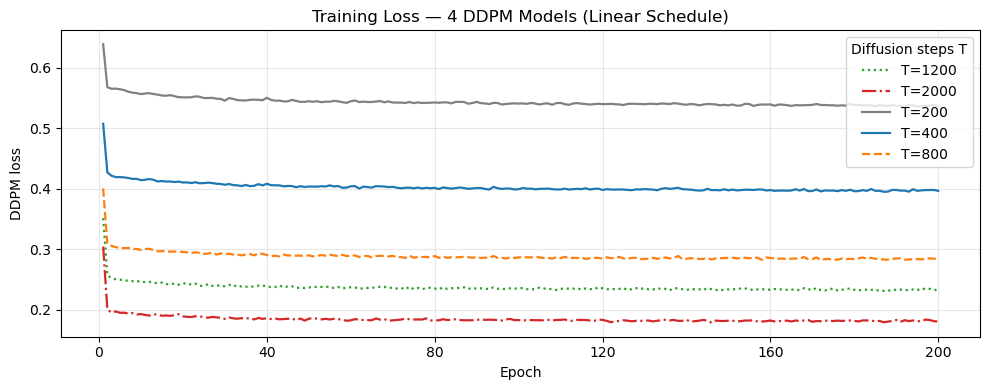


Saved: results/figures/training_loss_curves.png


In [2]:
# ── Checkpoint list ──────────────────────────────────────────────────────────
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

model_dir   = Path("artifacts/models")
log_dir     = Path("artifacts/training_logs")

checkpoints = sorted(model_dir.glob("ddpm_*.pt"))
print(f"Saved checkpoints ({len(checkpoints)}/4):")
for ckpt in checkpoints:
    print(f"  {ckpt.name}  ({ckpt.stat().st_size/1e6:.1f} MB)")

# ── Loss curves ──────────────────────────────────────────────────────────────
log_files = sorted(log_dir.glob("ddpm_*.csv"))
if not log_files:
    print("\nNo training logs yet — run Phase 4 first.")
else:
    T_styles  = {400: "-", 800: "--", 1200: ":", 2000: "-."}
    T_colors  = {400: "#1f77b4", 800: "#ff7f0e", 1200: "#2ca02c", 2000: "#d62728"}

    fig, ax = plt.subplots(figsize=(10, 4))

    for lf in log_files:
        # parse T from filename: ddpm_schedule-linear_T-{T}_seed-42.csv
        parts = lf.stem.split("_")
        T_val = int(parts[2].replace("T-", ""))

        df = pd.read_csv(lf)
        ax.plot(
            df["epoch"], df["train_loss"],
            color=T_colors.get(T_val, "gray"),
            linestyle=T_styles.get(T_val, "-"),
            linewidth=1.6,
            label=f"T={T_val}",
        )

    ax.set_title("Training Loss — 4 DDPM Models (Linear Schedule)", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DDPM loss")
    ax.legend(title="Diffusion steps T", fontsize=10)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = Path("results/figures/training_loss_curves.png")
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {fig_path}")


---
## Phase 4B · Train DDPM Covariance Denoising Models
`scripts/04b_train_denoising_models.py`

Trains **4** unconditional DDPM denoising models:

| schedule_type | T values |
|---|---|
| linear | 25, 50 |
| quadratic | 25, 50 |

**What this model does:**  
Instead of forecasting the next-month covariance, this DDPM learns the distribution of historical 126-day sample covariance matrices in standardized log-vech space.  At inference it acts as a **learned nonlinear regularizer** via SDEdit-style partial denoising: observe the current sample covariance → add mild diffusion noise to step `s_start = max(1, round(rho * T))` → reverse-denoise back to step 0.

Training data: same `condition_scaled` vectors used by the forecasting model (97k standardized log-vech of 126-day historical covariances).  No future target vectors needed.

> ⏱️ Much faster than Phase 4: T ≤ 50 steps, smaller input dim.  Expect ~1–3 min per model on GPU/MPS.

In [1]:
%run scripts/04b_train_denoising_models.py

2026-05-29 02:06:08 INFO     04b_train_denoising_models: ============================================================
2026-05-29 02:06:08 INFO     04b_train_denoising_models: STEP 4B – Train 4 unconditional DDPM denoising models (schedule ∈ {linear, quadratic}, T ∈ {25, 50})
2026-05-29 02:06:08 INFO     04b_train_denoising_models: ============================================================
2026-05-29 02:06:08 INFO     04b_train_denoising_models: Loading training dataset (condition_scaled vectors) …
2026-05-29 02:06:08 INFO     04b_train_denoising_models: Training pairs: 97674, condition_scaled shape (97674, 55)
2026-05-29 02:06:08 INFO     04b_train_denoising_models: 
[1/4] Training denoiser: schedule=linear, T=25


Denoiser linear T=25:   0%|          | 0/200 [00:00<?, ?ep/s]

2026-05-29 02:15:36 INFO     04b_train_denoising_models:   Saved denoiser checkpoint: artifacts/models/denoise_schedule-linear_T-25_seed-42.pt
2026-05-29 02:15:36 INFO     04b_train_denoising_models: 
[2/4] Training denoiser: schedule=linear, T=50


Denoiser linear T=50:   0%|          | 0/200 [00:00<?, ?ep/s]

2026-05-29 02:25:01 INFO     04b_train_denoising_models:   Saved denoiser checkpoint: artifacts/models/denoise_schedule-linear_T-50_seed-42.pt
2026-05-29 02:25:01 INFO     04b_train_denoising_models: 
[3/4] Training denoiser: schedule=quadratic, T=25


Denoiser quadratic T=25:   0%|          | 0/200 [00:00<?, ?ep/s]

2026-05-29 02:34:28 INFO     04b_train_denoising_models:   Saved denoiser checkpoint: artifacts/models/denoise_schedule-quadratic_T-25_seed-42.pt
2026-05-29 02:34:28 INFO     04b_train_denoising_models: 
[4/4] Training denoiser: schedule=quadratic, T=50


Denoiser quadratic T=50:   0%|          | 0/200 [00:00<?, ?ep/s]

2026-05-29 02:43:53 INFO     04b_train_denoising_models:   Saved denoiser checkpoint: artifacts/models/denoise_schedule-quadratic_T-50_seed-42.pt
2026-05-29 02:43:53 INFO     04b_train_denoising_models: 
Step 4B complete – trained 4 denoising model(s).


Denoiser checkpoints (4/4):
  denoise_schedule-linear_T-25_seed-42.pt  (0.21 MB)
  denoise_schedule-linear_T-50_seed-42.pt  (0.21 MB)
  denoise_schedule-quadratic_T-25_seed-42.pt  (0.21 MB)
  denoise_schedule-quadratic_T-50_seed-42.pt  (0.21 MB)


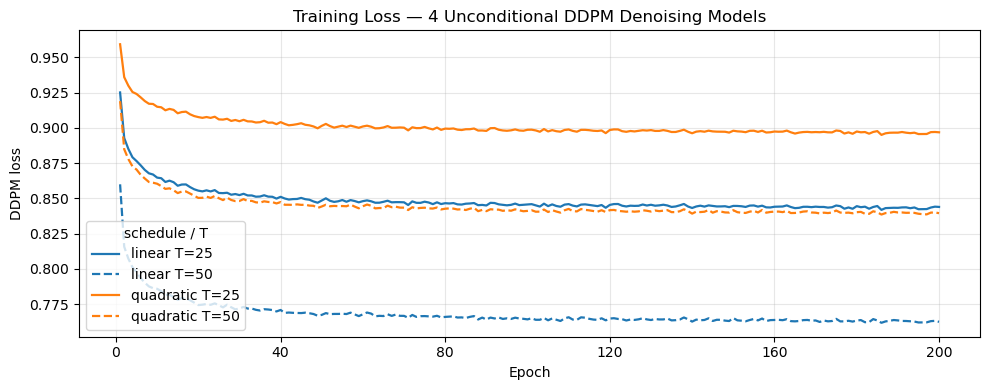


Saved: results/figures/denoiser_training_loss_curves.png


In [3]:
# ── Denoising checkpoint list + loss curves ───────────────────────────────
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

model_dir = Path("artifacts/models")
log_dir   = Path("artifacts/training_logs")

checkpoints = sorted(model_dir.glob("denoise_*.pt"))
print(f"Denoiser checkpoints ({len(checkpoints)}/4):")
for ckpt in checkpoints:
    print(f"  {ckpt.name}  ({ckpt.stat().st_size/1e6:.2f} MB)")

log_files = sorted(log_dir.glob("denoise_*.csv"))
if not log_files:
    print("\nNo denoiser training logs yet — run Phase 4B first.")
else:
    sched_colors = {"linear": "#1f77b4", "quadratic": "#ff7f0e"}
    T_styles = {25: "-", 50: "--"}

    fig, ax = plt.subplots(figsize=(10, 4))
    for lf in log_files:
        # filename: denoise_schedule-{sched}_T-{T}_seed-42.csv
        stem_parts = lf.stem.split("_")  # ['denoise', 'schedule-linear', 'T-25', 'seed-42']
        sched = stem_parts[1].replace("schedule-", "")
        T_val = int(stem_parts[2].replace("T-", ""))

        df_log = pd.read_csv(lf)
        ax.plot(
            df_log["epoch"], df_log["train_loss"],
            color=sched_colors.get(sched, "gray"),
            linestyle=T_styles.get(T_val, "-"),
            linewidth=1.6,
            label=f"{sched} T={T_val}",
        )

    ax.set_title("Training Loss — 4 Unconditional DDPM Denoising Models", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("DDPM loss")
    ax.legend(title="schedule / T", fontsize=10)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = Path("results/figures/denoiser_training_loss_curves.png")
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {fig_path}")

---
## Phase 5 · Validate Hyperparameters  
`scripts/05_validate_hyperparameters.py`

Evaluates **81** effective configurations:
- α=1 (sample covariance GMV) evaluated **once**
- 4 models × 4 α values × 5 M values = 80 diffusion-blend configs

**Selection metric:** annualized realized GMV portfolio volatility (2014–2020 only)  
No test data touched.


In [ ]:
%run scripts/05_validate_hyperparameters.py


2026-05-28 13:55:37 INFO     05_validate_hyperparameters: ============================================================
2026-05-28 13:55:37 INFO     05_validate_hyperparameters: STEP 5 – Validate hyperparameters (2014–2020)
2026-05-28 13:55:37 INFO     05_validate_hyperparameters: Device: mps
2026-05-28 13:55:37 INFO     05_validate_hyperparameters: Cache dir: results/validation/cache
2026-05-28 13:55:37 INFO     05_validate_hyperparameters: ============================================================
2026-05-28 13:55:38 INFO     05_validate_hyperparameters: ✓ Loading cached sample covariances from results/validation/cache/sample_covs.pkl
2026-05-28 13:55:38 INFO     05_validate_hyperparameters:   Loaded 83 dates, 2425 sleeves.
2026-05-28 13:55:38 INFO     05_validate_hyperparameters: 
Evaluating alpha=1 (sample covariance GMV) …
2026-05-28 13:55:59 INFO     05_validate_hyperparameters:   alpha=1.00  M=—  →  val_vol=0.160172  (sample covariance boundary)
2026-05-28 13:55:59 INFO     05_

Models:   0%|          | 0/4 [00:00<?, ?model/s]


── schedule=linear  T=400 ──────────────────────────────────────
  ✓ Loading cached scenarios from scenarios_schedule-linear_T-400.pkl


  Configs:   0%|          | 0/20 [00:00<?, ?cfg/s]

    schedule=linear        T=400  alpha=0.00  M= 1  →  val_vol=0.171999  (17.1999%)
    schedule=linear        T=400  alpha=0.25  M= 1  →  val_vol=0.166553  (16.6553%)
    schedule=linear        T=400  alpha=0.50  M= 1  →  val_vol=0.163802  (16.3802%)
    schedule=linear        T=400  alpha=0.75  M= 1  →  val_vol=0.161668  (16.1668%)
    schedule=linear        T=400  alpha=0.00  M= 5  →  val_vol=0.163773  (16.3773%)
    schedule=linear        T=400  alpha=0.25  M= 5  →  val_vol=0.162050  (16.2050%)
    schedule=linear        T=400  alpha=0.50  M= 5  →  val_vol=0.160995  (16.0995%)
    schedule=linear        T=400  alpha=0.75  M= 5  →  val_vol=0.160279  (16.0279%)
    schedule=linear        T=400  alpha=0.00  M=10  →  val_vol=0.163436  (16.3436%)
    schedule=linear        T=400  alpha=0.25  M=10  →  val_vol=0.161879  (16.1879%)
    schedule=linear        T=400  alpha=0.50  M=10  →  val_vol=0.160857  (16.0857%)
    schedule=linear        T=400  alpha=0.75  M=10  →  val_vol=0.160300  (16

2026-05-28 14:02:51 INFO     05_validate_hyperparameters:   Loading model checkpoint …


    schedule=linear        T=400  alpha=0.75  M=50  →  val_vol=0.160439  (16.0439%)

  ✓ schedule=linear  T=400  done — best this model: alpha=0.75  M=5  vol=0.160279  [20/81 configs evaluated]

  ── Current top-5 ──────────────────────────────────
   rk      schedule     T  alpha    M    val_vol
  ------------------------------------------------
    1  not_applicab     —   1.00    —   0.160172
    2        linear   400   0.75    5   0.160279
    3        linear   400   0.75   10   0.160300
    4        linear   400   0.75   20   0.160405
    5        linear   400   0.75   50   0.160439


── schedule=linear  T=800 ──────────────────────────────────────


  Generating:   0%|          | 0/2425 [00:00<?, ?sleeve/s]

In [ ]:
import pandas as pd, yaml

val_df = pd.read_csv("results/validation/validation_grid_results.csv")
print(f"Total configurations evaluated: {len(val_df)}")
print("\nTop-5 configurations:")
cols = ['rank', 'beta_schedule_type', 'diffusion_steps_T', 'alpha',
        'scenario_count_M', 'validation_annualized_realized_volatility',
        'selected_primary_model']
print(val_df[cols].head(10).to_string(index=False))

print("\n=== SELECTED MODEL ===")
with open("artifacts/selected_model/selected_model_config.yaml") as f:
    sel = yaml.safe_load(f)
for k, v in sel['selected_model'].items():
    print(f"  {k}: {v}")


FileNotFoundError: [Errno 2] No such file or directory: 'results/validation/validation_grid_results.csv'

---
## Phase 5B · Validate Denoising Hyperparameters
`scripts/05b_validate_denoising.py`

Evaluates **25** effective configurations:
- rho=0 boundary (raw sample covariance GMV) — evaluated **once**
- 4 denoising models × 3 rho values × 2 M values = 24 denoising configurations

**Hyperparameter grid:**

| Hyperparameter | Meaning | Grid |
|---|---|---|
| `schedule_type` | Beta schedule shape | `linear`, `quadratic` |
| `T` | Total diffusion steps | `25`, `50` |
| `rho` | Denoising strength = s_start / T | `0.05`, `0.10`, `0.20` |
| `M` | Independent denoised draws averaged | `1`, `20` |

At each rebalance date, the observed 126-day sample covariance is:
1. Transformed to standardized log-vech
2. Corrupted to step `s_start = max(1, round(rho * T))`
3. Reverse-denoised `M` times (each with independent noise)
4. Averaged in covariance matrix space

**Selection metric:** annualized realized GMV portfolio volatility (2014–2020 only)  
**Prerequisite:** Phase 5 must have run first to build `results/validation/cache/sample_covs.pkl`.

In [4]:
%run scripts/05b_validate_denoising.py

2026-05-29 02:44:31 INFO     05b_validate_denoising: ============================================================
2026-05-29 02:44:31 INFO     05b_validate_denoising: STEP 5B – Validate denoising hyperparameters (2014–2020)
2026-05-29 02:44:31 INFO     05b_validate_denoising: Device: mps
2026-05-29 02:44:31 INFO     05b_validate_denoising: ============================================================
2026-05-29 02:44:32 INFO     05b_validate_denoising: Loading sample covariance cache from results/validation/cache/sample_covs.pkl …
2026-05-29 02:44:32 INFO     05b_validate_denoising:   Loaded 83 dates, 2425 sleeves.
2026-05-29 02:44:32 INFO     05b_validate_denoising: 
Evaluating rho=0 (raw sample covariance GMV boundary) …
2026-05-29 02:44:52 INFO     05b_validate_denoising:   rho=0.00  M=—  →  val_vol=0.160172  (sample covariance boundary)
2026-05-29 02:44:52 INFO     05b_validate_denoising: 
Evaluating 4 models × 3 rho × 2 M = 24 denoising configurations …


Models:   0%|          | 0/4 [00:00<?, ?model/s]

2026-05-29 02:44:52 INFO     05b_validate_denoising:   Loading denoiser checkpoint: denoise_schedule-linear_T-25_seed-42.pt …



── schedule=linear  T=25 ──────────────────────────────────────


  Denoising rho=0.05:   0%|          | 0/2425 [00:00<?, ?sleeve/s]

...

2026-05-29 02:54:32 INFO     05b_validate_denoising:   ✓ Saved denoised cache rho=0.20 (2425 sleeve-dates) → results/validation/cache/denoised_schedule-quadratic_T-50_rho-0.20.pkl


  Configs:   0%|          | 0/6 [00:00<?, ?cfg/s]

    schedule=quadratic   T=50  rho=0.05  M= 1  →  val_vol=0.160192  (16.0192%)
    schedule=quadratic   T=50  rho=0.05  M=20  →  val_vol=0.160145  (16.0145%) ◀ best so far
    schedule=quadratic   T=50  rho=0.10  M= 1  →  val_vol=0.160197  (16.0197%)
    schedule=quadratic   T=50  rho=0.10  M=20  →  val_vol=0.160136  (16.0136%) ◀ best so far
    schedule=quadratic   T=50  rho=0.20  M= 1  →  val_vol=0.160363  (16.0363%)


2026-05-29 02:56:32 INFO     05b_validate_denoising: 
2026-05-29 02:56:32 INFO     05b_validate_denoising: FINAL DENOISING VALIDATION RANKING (top 10)
2026-05-29 02:56:32 INFO     05b_validate_denoising: ============================================================
2026-05-29 02:56:32 INFO     05b_validate_denoising:   # 1  quadratic      T=50  rho=0.10  M=20  vol=0.160136 ◀ SELECTED
2026-05-29 02:56:32 INFO     05b_validate_denoising:   # 2  quadratic      T=50  rho=0.05  M=20  vol=0.160145
2026-05-29 02:56:32 INFO     05b_validate_denoising:   # 3  linear         T=25  rho=0.05  M=20  vol=0.160156
2026-05-29 02:56:32 INFO     05b_validate_denoising:   # 4  linear         T=25  rho=0.05  M=1   vol=0.160158
2026-05-29 02:56:32 INFO     05b_validate_denoising:   # 5  quadratic      T=25  rho=0.05  M=20  vol=0.160163
2026-05-29 02:56:32 INFO     05b_validate_denoising:   # 6  quadratic      T=25  rho=0.05  M=1   vol=0.160165
2026-05-29 02:56:32 INFO     05b_validate_denoising:   # 7  not_

    schedule=quadratic   T=50  rho=0.20  M=20  →  val_vol=0.160181  (16.0181%)

  ✓ schedule=quadratic  T=50  done — best this model: rho=0.10  M=20  vol=0.160136  [24/24 configs evaluated]

  ── Current top-5 ──────────────────────────────────
   rk    schedule     T    rho    M    val_vol
  ----------------------------------------------
    1   quadratic    50   0.10   20   0.160136
    2   quadratic    50   0.05   20   0.160145
    3      linear    25   0.05   20   0.160156
    4      linear    25   0.05    1   0.160158
    5   quadratic    25   0.05   20   0.160163



In [5]:
import pandas as pd, yaml
from pathlib import Path

den_path = Path("results/validation/denoising_validation_grid_results.csv")
if not den_path.exists():
    print("Denoising validation results not yet generated. Run Phase 5B first.")
else:
    den_df = pd.read_csv(den_path)
    print(f"Total denoising configurations evaluated: {len(den_df)}")
    print("\nTop-5 denoising configurations:")
    cols = ['rank', 'schedule_type', 'diffusion_steps_T', 'rho',
            'draws_M', 'validation_annualized_realized_volatility', 'selected_primary_model']
    print(den_df[cols].head(10).to_string(index=False))

    print("\n=== SELECTED DENOISING MODEL ===")
    cfg_path = Path("artifacts/selected_denoising_model/selected_denoising_model_config.yaml")
    if cfg_path.exists():
        with open(cfg_path) as f:
            sel = yaml.safe_load(f)
        for k, v in sel['selected_denoising_model'].items():
            print(f"  {k}: {v}")

Total denoising configurations evaluated: 25

Top-5 denoising configurations:
 rank  schedule_type  diffusion_steps_T  rho  draws_M  validation_annualized_realized_volatility  selected_primary_model
    1      quadratic               50.0 0.10     20.0                                   0.160136                    True
    2      quadratic               50.0 0.05     20.0                                   0.160145                   False
    3         linear               25.0 0.05     20.0                                   0.160156                   False
    4         linear               25.0 0.05      1.0                                   0.160158                   False
    5      quadratic               25.0 0.05     20.0                                   0.160163                   False
    6      quadratic               25.0 0.05      1.0                                   0.160165                   False
    7 not_applicable                NaN 0.00      NaN                      

---
## Validation Comparison: Forecasting vs. Denoising Model

Side-by-side comparison of the two approaches on the **validation period (2014–2020)**.

| Model | Approach |
|---|---|
| **Conditional Diffusion Forecaster** | Conditions on S_hist, generates plausible *next-month* covariance distributions |
| **Unconditional DDPM Denoiser** | Learns distribution of S_hist itself; denoises observed covariance onto learned manifold |

The common baseline is raw sample covariance GMV (rho=0 / alpha=1).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

forecast_path = Path("results/validation/validation_grid_results.csv")
denoise_path  = Path("results/validation/denoising_validation_grid_results.csv")

if not forecast_path.exists() or not denoise_path.exists():
    print("Run Phase 5 and Phase 5B first to generate validation results.")
else:
    fc_df = pd.read_csv(forecast_path)
    dn_df = pd.read_csv(denoise_path)

    # ── Shared baseline ────────────────────────────────────────────────────
    sample_vol = fc_df.loc[fc_df["is_sample_covariance_boundary"] == True,
                           "validation_annualized_realized_volatility"].values[0]

    # ── Best from each approach ────────────────────────────────────────────
    fc_best = fc_df[fc_df["is_sample_covariance_boundary"] == False].nsmallest(
        1, "validation_annualized_realized_volatility"
    ).iloc[0]
    dn_best = dn_df[dn_df["is_sample_covariance_boundary"] == False].nsmallest(
        1, "validation_annualized_realized_volatility"
    ).iloc[0]

    print("=" * 72)
    print("VALIDATION PERIOD COMPARISON (2014–2020)")
    print("Metric: Annualized Realized GMV Portfolio Volatility (gross)")
    print("=" * 72)
    print(f"\n  Baseline – Sample Covariance GMV    : {sample_vol:.6f}  ({sample_vol*100:.4f}%)")

    fc_vol  = fc_best['validation_annualized_realized_volatility']
    fc_red  = 1.0 - fc_vol / sample_vol
    fc_sched = fc_best['beta_schedule_type']
    fc_T     = int(fc_best['diffusion_steps_T']) if pd.notna(fc_best.get('diffusion_steps_T')) else '—'
    fc_alpha = fc_best['alpha']
    fc_M     = int(fc_best['scenario_count_M']) if pd.notna(fc_best.get('scenario_count_M')) else '—'
    print(f"\n  Best Forecasting Model              : {fc_vol:.6f}  ({fc_vol*100:.4f}%)")
    print(f"    Config : schedule={fc_sched}  T={fc_T}  alpha={fc_alpha:.2f}  M={fc_M}")
    print(f"    Vol reduction vs baseline : {fc_red:+.4%}")

    dn_vol   = dn_best['validation_annualized_realized_volatility']
    dn_red   = 1.0 - dn_vol / sample_vol
    dn_sched = dn_best['schedule_type']
    dn_T     = int(dn_best['diffusion_steps_T']) if pd.notna(dn_best.get('diffusion_steps_T')) else '—'
    dn_rho   = dn_best['rho']
    dn_M     = int(dn_best['draws_M']) if pd.notna(dn_best.get('draws_M')) else '—'
    print(f"\n  Best Denoising Model                : {dn_vol:.6f}  ({dn_vol*100:.4f}%)")
    print(f"    Config : schedule={dn_sched}  T={dn_T}  rho={dn_rho:.2f}  M={dn_M}")
    print(f"    Vol reduction vs baseline : {dn_red:+.4%}")

    print("\n" + "=" * 72)
    winner = "Forecasting" if fc_vol < dn_vol else ("Denoising" if dn_vol < fc_vol else "Tie")
    diff   = abs(fc_vol - dn_vol)
    print(f"  Lower val-vol : {winner}  (difference {diff:.6f})")
    print("=" * 72)

    # ── Bar chart ──────────────────────────────────────────────────────────
    methods = ["Sample Cov\nGMV (baseline)", "Best\nForecasting", "Best\nDenoising"]
    vols    = [sample_vol, fc_vol, dn_vol]
    colors  = ["#aec7e8", "#1f77b4", "#ff7f0e"]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(methods, [v * 100 for v in vols], color=colors, edgecolor="black", linewidth=0.7)
    for bar, vol in zip(bars, vols):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{vol*100:.3f}%", ha="center", va="bottom", fontsize=10)

    ax.set_ylabel("Annualized Realized Volatility (%)")
    ax.set_title("Validation Period (2014–2020): Forecasting vs. Denoising GMV", fontsize=11)
    ax.set_ylim(min(vols) * 100 * 0.97, max(vols) * 100 * 1.03)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    fig_path = Path("results/figures/validation_forecasting_vs_denoising.png")
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {fig_path}")

    # ── Rho sensitivity table for denoising ───────────────────────────────
    print("\nDenoising val-vol by rho (best M for each rho, across all schedule/T):")
    rho_table = (
        dn_df[dn_df["is_sample_covariance_boundary"] == False]
        .groupby("rho")["validation_annualized_realized_volatility"]
        .min()
        .reset_index()
    )
    rho_table["vs_baseline"] = 1.0 - rho_table["validation_annualized_realized_volatility"] / sample_vol
    print(rho_table.to_string(index=False))

Run Phase 5 and Phase 5B first to generate validation results.


---
## Phase 6 · Final Test Backtest  
`scripts/06_run_final_test.py`

**THE TEST PERIOD (2021–2025) IS OPENED HERE FOR THE FIRST TIME.**

Runs:
- Stabilized Conditional Diffusion GMV (selected config)
- Equal Weight
- Sample Covariance GMV
- Ledoit-Wolf Linear Shrinkage GMV
- Ablations: pure diffusion (α=0), single scenario (M=1), pure sample (α=1)

> Do NOT modify this script or re-run it after viewing results.


In [ ]:
%run scripts/06_run_final_test.py


In [ ]:
import pandas as pd
summary = pd.read_csv("results/test/test_performance_summary.csv")
display_cols = [
    'method',
    'annualized_volatility_gross',
    'annualized_return_gross',
    'sharpe_gross',
    'average_turnover',
    'annualized_return_net_10bps',
]
print(summary[display_cols].to_string(index=False))


---
## Phase 7 · Generate Report & Figures  
`scripts/07_generate_report.py`


In [ ]:
%run scripts/07_generate_report.py


In [ ]:
from pathlib import Path
figs = sorted(Path("results/figures").glob("*.png"))
print(f"Generated {len(figs)} figures:")
for f in figs:
    print(f"  {f.name}")

print("\nReport:", Path("reports/final_results.md").exists())


### Key figures (inline preview)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

fig_files = [
    "results/figures/test_cumulative_wealth_gross.png",
    "results/figures/test_rolling_63day_volatility.png",
    "results/figures/validation_configuration_volatility_ranking.png",
]

for fp in fig_files:
    p = Path(fp)
    if p.exists():
        img = mpimg.imread(p)
        plt.figure(figsize=(12, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(p.stem.replace('_', ' ').title(), fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print(f"(not found: {fp})")


---
## ✓ Unit Tests  
Runs all 11 test files from `tests/`.  
These use synthetic data and do not require the CRSP file.


In [ ]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v", "--tb=short"],
    capture_output=True, text=True, cwd=str(PROJECT_ROOT)
)
print(result.stdout[-6000:] if len(result.stdout) > 6000 else result.stdout)
if result.returncode != 0 and result.stderr:
    print("STDERR:", result.stderr[-2000:])


---
## 📊 Final Results Summary


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

test_path = Path("results/test/test_performance_summary.csv")
if not test_path.exists():
    print("Test results not yet generated. Run Phase 6 first.")
else:
    df = pd.read_csv(test_path)

    # Pretty-print the full table
    df_display = df.copy()
    for col in df_display.select_dtypes(float).columns:
        if 'vol' in col or 'return' in col or 'sharpe' in col or 'cvar' in col or 'drawdown' in col:
            df_display[col] = df_display[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
        elif 'turnover' in col or 'hhi' in col or 'weight' in col or 'reduction' in col:
            df_display[col] = df_display[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")

    print("=" * 90)
    print("FINAL TEST PERFORMANCE (2021–2025)  |  untouched out-of-sample")
    print("=" * 90)
    pd.set_option('display.max_columns', 15)
    pd.set_option('display.width', 200)
    pd.set_option('display.max_colwidth', 35)
    print(df_display.to_string(index=False))

    # Highlight key comparison
    print("\n" + "=" * 70)
    print("KEY METRIC: Annualized Realized Volatility (gross)")
    print("=" * 70)
    if 'annualized_volatility_gross' in df.columns:
        vol_df = df[['method', 'annualized_volatility_gross',
                     'volatility_reduction_vs_sample_gmv']].copy()
        vol_df = vol_df.sort_values('annualized_volatility_gross')
        for _, row in vol_df.iterrows():
            vol = row['annualized_volatility_gross']
            red = row['volatility_reduction_vs_sample_gmv']
            bar = "█" * int(vol * 200)
            red_str = f"({red:+.2%} vs Sample GMV)" if pd.notna(red) and red != 0 else ""
            print(f"  {row['method']:<40s} {vol:.4f}  {red_str}")


In [ ]:
# Show selected model config
import yaml
from pathlib import Path

cfg_path = Path("artifacts/selected_model/selected_model_config.yaml")
if cfg_path.exists():
    with open(cfg_path) as f:
        sel = yaml.safe_load(f)
    print("Selected configuration:")
    for k, v in sel['selected_model'].items():
        print(f"  {k:50s}: {v}")
else:
    print("Selected model config not found. Run Phase 5 first.")


---
## Done ✓

All pipeline phases complete. Key outputs:

| File | Description |
|---|---|
| `results/test/test_performance_summary.csv` | Primary results table |
| `results/figures/test_cumulative_wealth_gross.png` | Wealth curve |
| `results/figures/test_rolling_63day_volatility.png` | Rolling vol comparison |
| `reports/final_results.md` | Full Markdown report |
| `artifacts/selected_model/selected_model_config.yaml` | Chosen hyperparameters |
| `results/validation/validation_grid_results.csv` | All 181 val configs ranked |
| `results/diagnostics/` | Scenario dispersion, repairs, condition numbers |
